Capteur BITalino connecté
START
Calibration terminée, début de l'analyse en temps réel...
Valeurs de calibration: {'EDA': np.float64(875.6687358916479), 'HR': np.float64(96.65294433506354), 'SDNN': np.float64(188.71070026647067), 'RMSSD': np.float64(213.61971963136878), 'PNN50': np.float64(42.30769230769231)}
Tentative de reconnexion automatique...
Capteur BITalino connecté
START
Tentative de reconnexion automatique...
Capteur BITalino connecté
START
Tentative de reconnexion automatique...
Capteur BITalino connecté
START
Tentative de reconnexion automatique...
Capteur BITalino connecté
START
STOP
Données enregistrées dans le fichier 'stress_log_20250307_162321.txt'
Graphique enregistré dans le fichier 'stress_graph_20250307_162321.png'


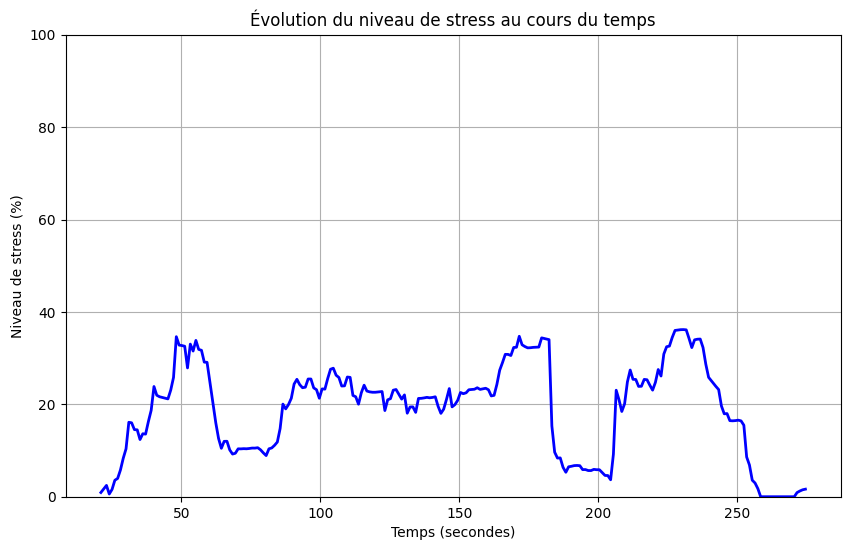

In [ ]:
import bitalino
import numpy as np
import time
import pygame
import math
import neurokit2 as nk
from scipy.signal import find_peaks
import datetime
import matplotlib.pyplot as plt
from collections import deque
import portalocker

# Création du fichier log avec un horodatage
log_filename = f"stress_log.txt"
log_file = open(log_filename, "w")
# Verrouiller le fichier lors de l'écriture de l'en-tête
portalocker.lock(log_file, portalocker.LOCK_EX)
log_file.write("Timestamp,Temps,StressLevel\n")
log_file.flush()
portalocker.unlock(log_file)

# Adresse MAC du capteur
macAddress = "98:D3:11:FE:03:67"

# Tentative de connexion au capteur BITalino
def connect_to_bitalino(macAddress):
    try:
        device = bitalino.BITalino(macAddress)
        time.sleep(1)
        print("Capteur BITalino connecté")
        return device
    except Exception as e:
        print(f"Erreur de connexion au capteur: {e}")
        return None

device = connect_to_bitalino(macAddress)

# Paramètres de lecture
srate = 1000
nframes = 10

# Démarrage de l'acquisition des données
def start_acquisition(device, srate):
    try:
        device.start(srate, [0, 1])  # Lire les broches 0 (EDA) et 1 (ECG)
        print("START")
    except Exception as e:
        print(f"Erreur lors du démarrage de l'acquisition: {e}")
        exit()

start_acquisition(device, srate)

# Initialisation de Pygame
pygame.init()

# Définir la taille de la fenêtre à 90% de l'écran
screen_info = pygame.display.Info()
window_size = (int(screen_info.current_w * 0.9), int(screen_info.current_h * 0.9))
screen = pygame.display.set_mode(window_size)
pygame.display.set_caption("Système de détection de Stress - Interface Futuriste")

# Police pour afficher les données
font = pygame.font.SysFont("Arial", 30)
hud_font = pygame.font.SysFont("Press Start 2P", 25)
status_font = pygame.font.SysFont("Arial", 40)

# Couleurs
BACKGROUND_COLOR = (20, 20, 20)  # Fond sombre
TEXT_COLOR = (0, 255, 0)  # Texte vert fluo
HIGHLIGHT_COLOR = (255, 0, 0)  # Alerte rouge
NEON_BLUE = (0, 255, 255)  # Bleu néon
NEON_PURPLE = (255, 0, 255)  # Violet néon
ECG_COLOR = (255, 255, 0)  # Jaune pour l'ECG
CALM_COLOR = (0, 255, 150)  # Vert clair pour état calme
STRESS_COLOR = (255, 50, 50)  # Rouge pour état de stress

# Variables pour stocker les dernières valeurs EDA et ECG
last_EDA_value = 0.0
last_ECG_value = 0.0

# Liste pour stocker les valeurs ECG pour le tracé
ecg_values = []

# Buffer pour stocker 20 secondes de données ECG et EDA
ecg_buffer = []
eda_buffer = []

# Variables pour stocker les métriques HR et HRV
HR = 0
hrv_metrics = {"SDNN": 0, "RMSSD": 0, "PNN50": 0}

# Variables pour la calibration et l'analyse du stress
calibration_complete = False
calibration_values = {
    "EDA": 0,
    "HR": 0,
    "SDNN": 0,
    "RMSSD": 0,
    "PNN50": 0
}

# Historique des niveaux de stress pour le graphique
stress_history = deque(maxlen=300)  # Garde 5 minutes d'historique (300 secondes)
time_history = deque(maxlen=300)

# Variable pour suivre l'état d'acquisition
start_time = time.time()
analysis_started = False
recording_duration = 0
current_stress_level = 0  # 0-100, 0 = calme, 100 = stress extrême

# Horodatage pour le calcul toutes les secondes
last_calculation_time = time.time()
last_reconnect_time = time.time()

# Fonction pour calculer le HR à partir des données ECG brutes
def calculate_hr_from_raw(ecg_data, sampling_rate=1000):
    """
    Calcule directement le rythme cardiaque à partir des données ECG brutes.

    Args:
        ecg_data: Données ECG brutes
        sampling_rate: Fréquence d'échantillonnage en Hz

    Returns:
        HR, SDNN, RMSSD, PNN50
    """
    if len(ecg_data) < sampling_rate:  # Au moins 1 seconde de données
        return 0, 0, 0, 0

    try:
        # Normalisation des données
        normalized_ecg = (ecg_data - np.mean(ecg_data)) / np.std(ecg_data)

        # Trouver les pics R (QRS complexes)
        # Ajuster height et distance selon les caractéristiques de votre signal
        peaks, _ = find_peaks(normalized_ecg, height=0.5, distance=sampling_rate//3)

        if len(peaks) < 2:
            # Essayer avec des paramètres plus sensibles si aucun pic n'est trouvé
            peaks, _ = find_peaks(normalized_ecg, height=0.3, distance=sampling_rate//4)

        if len(peaks) < 2:
            print("Aucun pic R trouvé dans les données ECG brutes.")
            return 0, 0, 0, 0

        # Calculer les intervalles RR en secondes
        rr_intervals = np.diff(peaks) / sampling_rate

        # Calculer le HR en BPM (60 secondes / intervalle RR moyen)
        hr = 60 / np.mean(rr_intervals)

        # Calculer les métriques HRV de base
        sdnn = np.std(rr_intervals) * 1000  # en ms

        # RMSSD: Racine carrée de la moyenne des carrés des différences entre intervalles RR successifs
        rmssd = np.sqrt(np.mean(np.square(np.diff(rr_intervals)))) * 1000  # en ms

        # PNN50: Pourcentage des intervalles RR qui diffèrent de plus de 50 ms
        if len(rr_intervals) < 2:
            pnn50 = 0
        else:
            # Convertir les intervalles RR en ms pour le calcul
            rr_intervals_ms = rr_intervals * 1000
            # Calculer les différences absolues entre intervalles RR successifs
            nn_diffs = np.abs(np.diff(rr_intervals_ms))
            # Compter combien de différences sont > 50ms
            nn50 = sum(nn_diffs > 50)
            # Calculer le pourcentage
            pnn50 = (nn50 / len(nn_diffs)) * 100 if len(nn_diffs) > 0 else 0

        return hr, sdnn, rmssd, pnn50

    except Exception as e:
        print(f"Erreur dans le calcul direct du HR: {e}")
        return 0, 0, 0, 0

# Fonction pour analyser le niveau de stress basé sur les paramètres physiologiques
def analyze_stress_level(eda, hr, sdnn, rmssd, pnn50, baseline):
    """
    Calcule le niveau de stress basé sur les paramètres physiologiques
    comparés aux valeurs de référence (baseline).

    Returns:
        Niveau de stress (0-100)
    """
    # Pondération de chaque paramètre
    weights = {
        "EDA": 0.3,    # EDA plus élevée = plus de stress
        "HR": 0.25,    # FC plus élevée = plus de stress
        "SDNN": 0.15,  # SDNN plus bas = plus de stress (relation inverse)
        "RMSSD": 0.15, # RMSSD plus bas = plus de stress (relation inverse)
        "PNN50": 0.15  # PNN50 plus bas = plus de stress (relation inverse)
    }

    # Valeurs de base (après calibration)
    eda_baseline = baseline["EDA"]
    hr_baseline = baseline["HR"]
    sdnn_baseline = baseline["SDNN"]
    rmssd_baseline = baseline["RMSSD"]
    pnn50_baseline = baseline["PNN50"]

    # Éviter les divisions par zéro
    sdnn_baseline = max(sdnn_baseline, 1)
    rmssd_baseline = max(rmssd_baseline, 1)
    pnn50_baseline = max(pnn50_baseline, 1)

    # Calculer les différences par rapport à la référence
    # Pour EDA et HR, l'augmentation indique du stress
    eda_change = max(0, (eda - eda_baseline) / max(eda_baseline, 1)) * 100
    hr_change = max(0, (hr - hr_baseline) / max(hr_baseline, 1)) * 100

    # Pour les indicateurs de HRV, la diminution indique du stress
    sdnn_change = max(0, (sdnn_baseline - sdnn) / sdnn_baseline) * 100
    rmssd_change = max(0, (rmssd_baseline - rmssd) / rmssd_baseline) * 100
    pnn50_change = max(0, (pnn50_baseline - pnn50) / pnn50_baseline) * 100

    # Limiter les changements à 100% pour éviter les valeurs extrêmes
    eda_change = min(eda_change, 100)
    hr_change = min(hr_change, 100)
    sdnn_change = min(sdnn_change, 100)
    rmssd_change = min(rmssd_change, 100)
    pnn50_change = min(pnn50_change, 100)

    # Calculer le niveau de stress pondéré
    stress_level = (
        weights["EDA"] * eda_change +
        weights["HR"] * hr_change +
        weights["SDNN"] * sdnn_change +
        weights["RMSSD"] * rmssd_change +
        weights["PNN50"] * pnn50_change
    )

    # Limiter le niveau de stress entre 0 et 100
    stress_level = max(0, min(stress_level, 100))

    return stress_level

# Fonction pour dessiner le fond
def draw_background():
    screen.fill(BACKGROUND_COLOR)


# Afficher l'interface HUD de manière élégante
def draw_hud(EDA_value, ECG_value, HR, HRV_metrics, recording_duration, analysis_started, calibration_complete, stress_level):
    # Titre
    title_text = hud_font.render("SYSTÈME DE DÉTECTION DE STRESS", True, TEXT_COLOR)
    screen.blit(title_text, (30, 30))

    # Compteur de temps d'enregistrement
    time_text = font.render(f"Temps: {recording_duration:.1f}s", True, TEXT_COLOR)
    screen.blit(time_text, (30, 70))

    # Statut du système
    if not calibration_complete:
        status_text = status_font.render("CALIBRATION EN COURS...", True, NEON_BLUE)
        screen.blit(status_text, (window_size[0]//2 - 250, window_size[1]//2 - 50))

    # Valeur EDA actuelle
    EDA_text = font.render(f"EDA: {EDA_value:.2f}", True, TEXT_COLOR)
    screen.blit(EDA_text, (30, 120))

    # Valeur ECG actuelle
    ECG_text = font.render(f"ECG: {ECG_value:.2f}", True, ECG_COLOR)
    screen.blit(ECG_text, (30, window_size[1] - 300))

    # Valeur HR actuelle
    HR_text = font.render(f"HR: {HR:.2f} bpm", True, TEXT_COLOR)
    screen.blit(HR_text, (30, window_size[1] - 250))

    # Valeurs HRV actuelles
    SDNN_text = font.render(f"SDNN: {HRV_metrics['SDNN']:.2f}", True, TEXT_COLOR)
    screen.blit(SDNN_text, (30, window_size[1] - 200))

    RMSSD_text = font.render(f"RMSSD: {HRV_metrics['RMSSD']:.2f}", True, TEXT_COLOR)
    screen.blit(RMSSD_text, (30, window_size[1] - 150))

    # Nouvelle métrique PNN50
    PNN50_text = font.render(f"PNN50: {HRV_metrics['PNN50']:.2f}%", True, TEXT_COLOR)
    screen.blit(PNN50_text, (30, window_size[1] - 100))

    # Afficher le niveau de stress si la calibration est terminée
    if calibration_complete:
        # Couleur basée sur le niveau de stress
        color_factor = stress_level / 100.0
        stress_color = (
            int(CALM_COLOR[0] + (STRESS_COLOR[0] - CALM_COLOR[0]) * color_factor),
            int(CALM_COLOR[1] + (STRESS_COLOR[1] - CALM_COLOR[1]) * color_factor),
            int(CALM_COLOR[2] + (STRESS_COLOR[2] - CALM_COLOR[2]) * color_factor)
        )

        stress_text = status_font.render(f"STRESS: {stress_level:.1f}%", True, stress_color)
        screen.blit(stress_text, (window_size[0] - 350, 50))

        # Texte d'état basé sur le niveau de stress
        if stress_level < 15:
            state_text = font.render("État: CALME", True, CALM_COLOR)
        elif stress_level < 35:
            state_text = font.render("État: TENSION MODÉRÉE", True, (255, 255, 0))
        elif stress_level < 65:
            state_text = font.render("État: STRESS ÉLEVÉ", True, STRESS_COLOR)
        elif stress_level < 80:
            state_text = font.render("État: STRESS TRÈS ÉLEVÉ", True, HIGHLIGHT_COLOR)
        else:
            state_text = font.render("État: STRESS CRITIQUE", True, (255, 0, 0))
        screen.blit(state_text, (window_size[0] - 350, 150))

# Fonction pour dessiner le tracé de l'ECG
def draw_ecg_trace(ecg_values):
    if len(ecg_values) < 2:
        return

    # Définir la zone de tracé de l'ECG
    ecg_area_height = 100  # Hauteur de la zone de tracé de l'ECG
    ecg_area_top = window_size[1] - 150  # Position verticale du haut de la zone de tracé

    # Tracer les valeurs ECG dans la zone définie
    scale_factor = 5  # Facteur d'échelle pour ajuster la hauteur de la courbe
    for i in range(1, len(ecg_values)):
        x1 = window_size[0] - (len(ecg_values) - i) * 2  # Ajustement pour un défilement plus rapide
        x2 = window_size[0] - (len(ecg_values) - i - 1) * 2
        y1 = ecg_area_top + ecg_area_height / 2 - ecg_values[i - 1] / scale_factor
        y2 = ecg_area_top + ecg_area_height / 2 - ecg_values[i] / scale_factor
        pygame.draw.line(screen, ECG_COLOR, (x1, y1), (x2, y2), 2)

# Fonction pour dessiner la courbe de stress
def draw_stress_curve(stress_history, time_history):
    if len(stress_history) < 2:
        return

    # Définir la zone de la courbe de stress
    stress_area_width = 500
    stress_area_height = 150
    stress_area_left = 800
    stress_area_top = 250

    # Dessiner le cadre
    pygame.draw.rect(screen, TEXT_COLOR, (stress_area_left, stress_area_top,
                                        stress_area_width, stress_area_height), 1)

    # Dessiner les axes
    pygame.draw.line(screen, TEXT_COLOR,
                    (stress_area_left, stress_area_top + stress_area_height),
                    (stress_area_left + stress_area_width, stress_area_top + stress_area_height), 1)
    pygame.draw.line(screen, TEXT_COLOR,
                    (stress_area_left, stress_area_top),
                    (stress_area_left, stress_area_top + stress_area_height), 1)

    # Dessiner le titre
    curve_title = font.render("Évolution du niveau de stress", True, TEXT_COLOR)
    screen.blit(curve_title, (stress_area_left, stress_area_top - 50))

    # Marquer les graduations sur l'axe Y
    for i in range(0, 101, 25):
        y_pos = stress_area_top + stress_area_height - (i / 100 * stress_area_height)
        pygame.draw.line(screen, TEXT_COLOR, (stress_area_left - 5, y_pos), (stress_area_left, y_pos), 1)
        y_label = font.render(f"{i}", True, TEXT_COLOR)
        screen.blit(y_label, (stress_area_left - 25, y_pos - 10))

    # Tracer la courbe de stress
    points = []
    for i, stress in enumerate(stress_history):
        if i >= len(stress_history) - stress_area_width//2:  # Afficher seulement les dernières n secondes
            x = stress_area_left + (i - (len(stress_history) - stress_area_width//2)) * 2
            y = stress_area_top + stress_area_height - (stress / 100 * stress_area_height)
            points.append((x, y))

    if len(points) >= 2:
        # Dessiner la ligne
        pygame.draw.lines(screen, NEON_BLUE, False, points, 2)

        # Dessiner le dernier point avec une couleur basée sur le niveau de stress
        last_stress = stress_history[-1]
        color_factor = last_stress / 100.0
        point_color = (
            int(CALM_COLOR[0] + (STRESS_COLOR[0] - CALM_COLOR[0]) * color_factor),
            int(CALM_COLOR[1] + (STRESS_COLOR[1] - CALM_COLOR[1]) * color_factor),
            int(CALM_COLOR[2] + (STRESS_COLOR[2] - CALM_COLOR[2]) * color_factor)
        )
        pygame.draw.circle(screen, point_color, points[-1], 5)

# Boucle principale pour afficher les données en temps réel
running = True
while running:
    # Mettre à jour le temps d'enregistrement
    current_time = time.time()
    recording_duration = current_time - start_time

    # Vérifier si 20 secondes se sont écoulées pour commencer l'analyse
    if recording_duration >= 20 and not calibration_complete:
        calibration_complete = True
        print("Calibration terminée, début de l'analyse en temps réel...")

        # Calculer les valeurs de référence à partir des buffers
        if len(ecg_buffer) >= 20 * srate * 0.8:  # Au moins 80% des données attendues
            calculated_hr, calculated_sdnn, calculated_rmssd, calculated_pnn50 = calculate_hr_from_raw(np.array(ecg_buffer), srate)
            calibration_values["HR"] = calculated_hr if calculated_hr > 0 else 70  # Valeur par défaut si échec
            calibration_values["SDNN"] = calculated_sdnn if calculated_sdnn > 0 else 50
            calibration_values["RMSSD"] = calculated_rmssd if calculated_rmssd > 0 else 30
            calibration_values["PNN50"] = calculated_pnn50 if calculated_pnn50 > 0 else 10

        if len(eda_buffer) > 0:
            calibration_values["EDA"] = np.mean(eda_buffer)

        print(f"Valeurs de calibration: {calibration_values}")
        analysis_started = True

    # Gérer les événements Pygame (fermeture de la fenêtre, etc.)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    # Vérifier la connexion toutes les minutes
    if current_time - last_reconnect_time >= 60:
        print("Tentative de reconnexion automatique...")
        device.stop()
        device.close()
        device = connect_to_bitalino(macAddress)
        if device:
            start_acquisition(device, srate)
        last_reconnect_time = current_time

    try:
        # Lire les données du capteur
        data = device.read(nframes)

        # Si la moyenne est inférieure à 1, on arrête la lecture
        if np.mean(data[:, 1]) < 1:
            break

        EDA = data[:, 5]
        ECG = data[:, 6]
        last_EDA_value = EDA[-1]  # Dernière valeur EDA
        last_ECG_value = ECG[-1]  # Dernière valeur ECG

        # Ajouter la dernière valeur EDA au buffer
        for val in EDA:
            eda_buffer.append(val)

        # Ajouter la dernière valeur ECG à la liste pour le tracé
        ecg_values.append(last_ECG_value)
        if len(ecg_values) > window_size[0]:
            ecg_values.pop(0)  # Limiter la taille de la liste

        # Ajouter toutes les valeurs ECG au buffer pour le calcul des métriques
        for val in ECG:
            ecg_buffer.append(val)

        # Limiter les buffers à 20 secondes de données (20 * fréquence d'échantillonnage)
        buffer_size = 20 * srate
        if len(ecg_buffer) > buffer_size:
            # Supprimer les valeurs les plus anciennes pour maintenir 20 secondes de données
            ecg_buffer = ecg_buffer[-buffer_size:]

        if len(eda_buffer) > buffer_size:
            eda_buffer = eda_buffer[-buffer_size:]

        # Calculer HR, HRV et niveau de stress toutes les secondes, mais seulement après calibration
        if analysis_started and current_time - last_calculation_time >= 1.0:  # Calcul toutes les secondes
            if len(ecg_buffer) >= buffer_size * 0.9:  # Au moins 80% de la taille du buffer souhaitée
                # Utilisez la méthode directe de calcul du HR et HRV
                calculated_hr, calculated_sdnn, calculated_rmssd, calculated_pnn50 = calculate_hr_from_raw(np.array(ecg_buffer), srate)

                # Mettre à jour les valeurs seulement si le calcul a réussi
                if calculated_hr > 0:
                    HR = calculated_hr
                    hrv_metrics["SDNN"] = calculated_sdnn
                    hrv_metrics["RMSSD"] = calculated_rmssd
                    hrv_metrics["PNN50"] = calculated_pnn50

                    # Calculer le niveau de stress
                    mean_eda = np.mean(eda_buffer[-int(len(eda_buffer)*0.2):])  # Moyenne des 20% dernières valeurs
                    current_stress_level = analyze_stress_level(
                        mean_eda, HR, calculated_sdnn, calculated_rmssd, calculated_pnn50,
                        calibration_values
                    )

                    # Ajouter à l'historique
                    stress_history.append(current_stress_level)
                    time_history.append(recording_duration)

                    # Enregistrer dans le fichier log
                    timestamp_now = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
                    # Utilisation de portalocker pour verrouiller le fichier pendant l'écriture
                    portalocker.lock(log_file, portalocker.LOCK_EX)
                    log_file.write(f"{timestamp_now},{recording_duration:.1f},{current_stress_level:.2f}\n")
                    log_file.flush()
                    portalocker.unlock(log_file)

            # Mettre à jour l'horodatage du dernier calcul
            last_calculation_time = current_time

    except Exception as e:
        print(f"Erreur de lecture des données: {e}")
        break

    # Dessiner le fond, les cercles dynamiques et l'interface
    draw_background()
    draw_hud(last_EDA_value, last_ECG_value, HR, hrv_metrics, recording_duration, analysis_started, calibration_complete, current_stress_level)
    draw_ecg_trace(ecg_values)

    # Dessiner la courbe de stress si la calibration est terminée
    if calibration_complete:
        draw_stress_curve(stress_history, time_history)

    # Mettre à jour l'affichage
    pygame.display.flip()

    # Attendre un peu avant de relire les données
    pygame.time.delay(10)

# Arrêter le capteur et fermer Pygame proprement
print("STOP")
device.trigger([0, 0])
device.stop()
device.close()

# Fermer le fichier log
log_file.close()
print(f"Données enregistrées dans le fichier '{log_filename}'")

# Génération d'un graphique récapitulatif
if len(stress_history) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(list(time_history), list(stress_history), 'b-', linewidth=2)
    plt.title('Évolution du niveau de stress au cours du temps')
    plt.xlabel('Temps (secondes)')
    plt.ylabel('Niveau de stress (%)')
    plt.grid(True)
    plt.ylim(0, 100)

    graph_filename = f"stress_graph.png"
    plt.savefig(graph_filename)
    print(f"Graphique enregistré dans le fichier '{graph_filename}'")

pygame.quit()
